# 🏃 Human Activity Recognition — 3 Model Pipeline
### CNN · CNN-LSTM · CNN-LSTM+Attention

| Stage | Content |
|---|---|
| 1 | Setup & Imports |
| 2 | Download & Parse UCI HAR Dataset |
| 3 | Feature Engineering (Time + FFT) |
| 4 | **3 Models** — CNN · CNN-LSTM · CNN-LSTM+Attn |
| 5 | Training Loop — AdamW + Early Stopping |
| 6 | Evaluation + Auto Best-Model Selection |
| 7 | Plots — training curves, confusion matrix, comparison |
| 8 | Real-World predict_activity() Function |
| 9 | Robustness Testing |




---
##  Stage 1 — Setup & Imports

In [1]:
!pip install -q torch numpy matplotlib seaborn scikit-learn reportlab

import os, sys, json, time, math, copy, random, zipfile, urllib.request, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

BASE    = Path('/content/HAR')
DATA    = BASE / 'data'
RESULTS = BASE / 'results'
MODELS  = BASE / 'models'
for d in [DATA, RESULTS, MODELS, REPORT]:
    d.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
WIN       = 128          # window size (2.56 s at 50 Hz)
N_CH      = 9
N_CLASSES = 6
LABELS    = ['WALKING', 'WALK_UP', 'WALK_DOWN', 'SITTING', 'STANDING', 'LAYING']
SHORT     = ['WLK', 'WUP', 'WDN', 'SIT', 'STD', 'LAY']
COLORS    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}" + (f"  ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))
print("All folders created ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 75.7 MB/s eta 0:00:00
PyTorch  : 2.10.0+cu128
Device   : cuda  (Tesla T4)
All folders created ✓


---
##  Stage 2 — Download & Parse UCI HAR Dataset

In [2]:
DATASET_DIR  = DATA / 'UCI HAR Dataset'
SIGNAL_NAMES = [
    'body_acc_x',  'body_acc_y',  'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z',
]

if not DATASET_DIR.exists():
    URL = ('https://archive.ics.uci.edu/ml/machine-learning-databases'
           '/00240/UCI%20HAR%20Dataset.zip')
    print('Downloading UCI HAR Dataset …')
    def _prog(c, b, t):
        print(f'\r  {min(int(c * b * 100 / t), 100)}%', end='')
    urllib.request.urlretrieve(URL, DATA / 'uci.zip', reporthook=_prog)
    print()
    with zipfile.ZipFile(DATA / 'uci.zip') as z:
        z.extractall(DATA)
    (DATA / 'uci.zip').unlink()
    print('Download complete ✓')
else:
    print('Dataset already present ✓')


def _parse_signal_file(fp):
    """Parse one space-delimited raw signal file → (N, 128) float32."""
    rows = []
    with open(fp) as f:
        for line in f:
            rows.append([float(v) for v in line.strip().split()])
    return np.array(rows, dtype=np.float32)


def _parse_label_file(fp):
    """Parse label file → (N,) int64, 0-indexed."""
    with open(fp) as f:
        return np.array([int(l) - 1 for l in f], dtype=np.int64)


def load_split(split):
    """Load all 9 signal channels + labels for 'train' or 'test'."""
    sd = DATASET_DIR / split / 'Inertial Signals'
    X  = np.stack(
        [_parse_signal_file(sd / f'{s}_{split}.txt') for s in SIGNAL_NAMES],
        axis=-1,
    )
    y  = _parse_label_file(DATASET_DIR / split / f'y_{split}.txt')
    return X.astype(np.float32), y


print('Loading …')
X_train_raw, y_train = load_split('train')
X_test_raw,  y_test  = load_split('test')

# Validate — no NaN / Inf expected in UCI HAR
for name, X in [('train', X_train_raw), ('test', X_test_raw)]:
    bad = int(np.isnan(X).sum()) + int(np.isinf(X).sum())
    status = '✓' if bad == 0 else f'⚠  {bad} bad values found — imputing'
    print(f'  [{name}]  NaN/Inf count: {bad}  {status}')
    if bad > 0:
        for c in range(N_CH):
            mask = ~np.isfinite(X[:, :, c])
            if mask.any():
                X[:, :, c][mask] = np.nanmean(X[:, :, c])

print(f'\nX_train : {X_train_raw.shape}   y_train : {y_train.shape}')
print(f'X_test  : {X_test_raw.shape}    y_test  : {y_test.shape}')
print(f'Classes : {LABELS}')

  -6100582400%
Download complete ✓
Loading …
  [train]  NaN/Inf count: 0  ✓
  [test]  NaN/Inf count: 0  ✓

X_train : (7352, 128, 9)   y_train : (7352,)
X_test  : (2947, 128, 9)    y_test  : (2947,)
Classes : ['WALKING', 'WALK_UP', 'WALK_DOWN', 'SITTING', 'STANDING', 'LAYING']


---
##  Stage 3 — Feature Engineering

In [3]:
# ─────────────────────────────────────────────────────────────────────────
#  1. Z-score normalisation  (fit on train only — no data leakage)
#  2. FFT magnitude features (frequency domain)
#  3. Fusion: time(9) + FFT(9) → 18 channels
# ─────────────────────────────────────────────────────────────────────────

# ── 1. Per-channel Z-score ────────────────────────────────────────────────
flat     = X_train_raw.reshape(-1, N_CH)
CH_MEAN  = flat.mean(axis=0)                    # (9,)
CH_STD   = flat.std(axis=0) + 1e-8             # (9,)

def z_score(X):
    return ((X - CH_MEAN) / CH_STD).astype(np.float32)

X_train_t = z_score(X_train_raw)               # (N, 128, 9)  time-domain
X_test_t  = z_score(X_test_raw)

# ── 2. FFT magnitude features ─────────────────────────────────────────────
#  rfft gives WIN//2+1 bins; drop DC (bin 0) → keep 64 bins per channel
def _fft_features(X_raw):
    mag = np.abs(np.fft.rfft(X_raw, axis=1))[:, 1:WIN // 2 + 1, :]  # (N,64,9)
    return mag.astype(np.float32)

fft_tr_raw          = _fft_features(X_train_raw)
flat_f              = fft_tr_raw.reshape(-1, N_CH)
FFT_MEAN            = flat_f.mean(axis=0)
FFT_STD             = flat_f.std(axis=0) + 1e-8

def norm_fft(X_raw):
    return ((_fft_features(X_raw) - FFT_MEAN) / FFT_STD).astype(np.float32)

X_train_f = norm_fft(X_train_raw)              # (N, 64, 9)
X_test_f  = norm_fft(X_test_raw)

# ── 3. Fuse — zero-pad FFT from 64 → 128 then concat channels ────────────
def fuse(X_t, X_f):
    """(N,128,9) + (N,64,9) → (N,128,18)"""
    pad = np.zeros((len(X_f), WIN - X_f.shape[1], N_CH), np.float32)
    return np.concatenate([X_t, np.concatenate([X_f, pad], axis=1)], axis=2)

X_train = fuse(X_train_t, X_train_f)           # (N, 128, 18)
X_test  = fuse(X_test_t,  X_test_f)

IN_CH = X_train.shape[2]   # 18

print(f'Time features  : {X_train_t.shape}')
print(f'FFT features   : {X_train_f.shape}')
print(f'Fused input    : {X_train.shape}  ← used as model input')
print(f'Input channels : {IN_CH}  (9 time + 9 FFT)')

Time features  : (7352, 128, 9)
FFT features   : (7352, 64, 9)
Fused input    : (7352, 128, 18)  ← used as model input
Input channels : 18  (9 time + 9 FFT)


In [4]:
# ─────────────────────────────────────────────────────────────────────────
#  Augmentation helpers (applied during training only)
# ─────────────────────────────────────────────────────────────────────────

def aug_noise(x, sigma=0.03):
    """Add Gaussian noise — simulates sensor measurement variability."""
    return x + np.random.randn(*x.shape).astype(np.float32) * sigma

def aug_shift(x, max_shift=10):
    """Circular time shift — simulates different window start phase."""
    return np.roll(x, np.random.randint(-max_shift, max_shift), axis=0)


# ─────────────────────────────────────────────────────────────────────────
#  Stratified train / validation split  (15 % per class → validation)
# ─────────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(SEED)
tr_idx, val_idx = [], []
for c in range(N_CLASSES):
    idx = np.where(y_train == c)[0]
    rng.shuffle(idx)
    n_val = max(1, int(len(idx) * 0.15))
    val_idx.extend(idx[:n_val].tolist())
    tr_idx.extend(idx[n_val:].tolist())
tr_idx  = np.array(tr_idx)
val_idx = np.array(val_idx)

print(f'Train windows      : {len(tr_idx)}')
print(f'Validation windows : {len(val_idx)}')
print(f'Test windows       : {len(y_test)}')


# ────────────────────────────────────────────────────────────────────────
#  PyTorch Dataset & DataLoaders
# ─────────────────────────────────────────────────────────────────────────

class HARDataset(Dataset):
    """
    Wraps (N, T, C) fused arrays.
    Transposes to (N, C, T) so Conv1d receives channels-first tensors.
    Optional augmentation applied per-sample during training.
    """
    def __init__(self, X, y, augment=False):
        self.X       = X.astype(np.float32)
        self.y       = y.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        x = self.X[i].copy()
        if self.augment:
            if np.random.rand() < 0.5:
                x = aug_noise(x, sigma=0.03)   # 50 % chance of noise
            if np.random.rand() < 0.3:
                x = aug_shift(x, max_shift=10) # 30 % chance of shift
        # (T, C) → (C, T)
        return torch.tensor(x.T, dtype=torch.float32), torch.tensor(self.y[i])


def make_loaders(batch_size=64):
    kw = dict(num_workers=2, pin_memory=True)
    train_ds = HARDataset(X_train[tr_idx],  y_train[tr_idx],  augment=True)
    val_ds   = HARDataset(X_train[val_idx], y_train[val_idx], augment=False)
    test_ds  = HARDataset(X_test,           y_test,           augment=False)
    return (
        DataLoader(train_ds, batch_size, shuffle=True,  **kw),
        DataLoader(val_ds,   batch_size, shuffle=False, **kw),
        DataLoader(test_ds,  batch_size, shuffle=False, **kw),
    )

train_loader, val_loader, test_loader = make_loaders()
Xb, yb = next(iter(train_loader))
print(f'\nBatch X : {tuple(Xb.shape)}   (Batch, Channels=18, Time=128)')
print(f'Batch y : {tuple(yb.shape)}')

Train windows      : 6253
Validation windows : 1099
Test windows       : 2947

Batch X : (64, 18, 128)   (Batch, Channels=18, Time=128)
Batch y : (64,)


---
##  Stage 4 — Model Definitions

In [5]:
# ═════════════════════════════════════════════════════════════════════════
#  SHARED BUILDING BLOCKS
# ═════════════════════════════════════════════════════════════════════════

class ConvBlock(nn.Module):
    """
    Conv1d → BatchNorm1d → ReLU.
    BatchNorm stabilises training by normalising layer inputs,
    allowing higher learning rates and reducing init sensitivity.
    """
    def __init__(self, in_ch, out_ch, kernel=3, pad=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau) attention over an LSTM output sequence.

    Instead of discarding all timesteps except the last hidden state,
    attention computes a weighted sum of ALL hidden states.
    Weights are learned: the model discovers which timesteps matter most
    for each activity class (e.g. heel-strike peaks for walking).

    Maths:
        e_t = v · tanh(W · h_t)   ← energy score per timestep
        α   = softmax(e)           ← normalised attention weights
        c   = Σ α_t · h_t         ← context vector (weighted sum)
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, h_seq):           # h_seq : (B, T, H)
        energy = self.v(torch.tanh(self.W(h_seq)))  # (B, T, 1)
        alpha  = F.softmax(energy, dim=1)           # (B, T, 1)
        ctx    = (alpha * h_seq).sum(dim=1)         # (B, H)
        return ctx, alpha.squeeze(-1)               # (B,H), (B,T)

In [6]:
# ═════════════════════════════════════════════════════════════════════════
#  MODEL 1 — CNN  (Baseline)
#  Design   : 3 ConvBlocks (64→128→256), simple 2-layer classifier.
# ═════════════════════════════════════════════════════════════════════════

class CNNBaseline(nn.Module):
    def __init__(self, in_ch=IN_CH, n_cls=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_ch, 64),
            ConvBlock(64, 128),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),

            ConvBlock(128, 256),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),

            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, n_cls),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ═════════════════════════════════════════════════════════════════════════
#  MODEL 2 — CNN-LSTM  (Best non-attention model)
#  Purpose  : CNN extracts local features → LSTM captures temporal order.
#  Design   : Deep 5-block CNN (64→128→256→256→512), lstm_h=512,
#             LayerNorm before classifier, 3-layer GELU head.
#             Deliberately stronger than CNN baseline.
# ═════════════════════════════════════════════════════════════════════════

class CNNLSTM(nn.Module):
    def __init__(self, in_ch=IN_CH, n_cls=N_CLASSES, lstm_h=512):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(in_ch, 64),
            ConvBlock(64, 128),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            ConvBlock(128, 256),
            ConvBlock(256, 256),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            ConvBlock(256, 512),
            nn.AdaptiveAvgPool1d(32),      # keep 32 timesteps for LSTM
        )
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=lstm_h,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_h),
            nn.Linear(lstm_h, 256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 128),   nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, n_cls),
        )

    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        return self.classifier(h_n[-1])


# ═════════════════════════════════════════════════════════════════════════
#  MODEL 3 — CNN-LSTM + Attention
#  Purpose  : Attention over all LSTM hidden states — richer than last-step.
#  Design   : Same deep CNN as CNN-LSTM, BahdanauAttention with LayerNorm.
# ═════════════════════════════════════════════════════════════════════════

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W          = nn.Linear(hidden_dim, hidden_dim)
        self.v          = nn.Linear(hidden_dim, 1, bias=False)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, h_seq):
        energy = self.v(torch.tanh(self.W(self.layer_norm(h_seq))))
        alpha  = F.softmax(energy, dim=1)
        ctx    = (alpha * h_seq).sum(dim=1)
        return ctx, alpha.squeeze(-1)


class CNNLSTMAttn(nn.Module):
    def __init__(self, in_ch=IN_CH, n_cls=N_CLASSES, lstm_h=256):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(in_ch, 64),
            ConvBlock(64, 128),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            ConvBlock(128, 256),
            ConvBlock(256, 256),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            ConvBlock(256, 512),
            nn.AdaptiveAvgPool1d(32),
        )
        self.lstm = nn.LSTM(
            input_size=512, hidden_size=lstm_h,
            num_layers=2, batch_first=True, dropout=0.3,
        )
        self.attention  = BahdanauAttention(lstm_h)
        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_h),
            nn.Linear(lstm_h, 256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 128),   nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, n_cls),
        )
        self.last_attn = None

    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        h_seq, _ = self.lstm(x)
        ctx, alpha = self.attention(h_seq)
        self.last_attn = alpha.detach().cpu()
        return self.classifier(ctx)


# ─────────────────────────────────────────────────────────────────────────
#  Model registry
# ─────────────────────────────────────────────────────────────────────────
MODEL_ZOO = {
    'CNN':           CNNBaseline,
    'CNN-LSTM':      CNNLSTM,
    'CNN-LSTM+Attn': CNNLSTMAttn,
}

dummy = torch.randn(4, IN_CH, WIN)
print(f"{'Model':<18}  {'Parameters':>12}  Output")
print('─' * 45)
for name, cls in MODEL_ZOO.items():
    m   = cls()
    n_p = sum(p.numel() for p in m.parameters() if p.requires_grad)
    out = m(dummy)
    assert out.shape == (4, N_CLASSES)
    print(f"{name:<18}  {n_p:>12,}  {tuple(out.shape)}  ✓")


Model                 Parameters  Output
─────────────────────────────────────────────
CNN                      160,902  (4, 6)  ✓
CNN-LSTM               5,087,110  (4, 6)  ✓
CNN-LSTM+Attn          2,199,942  (4, 6)  ✓


---
##  Stage 5 — Training Loop

In [7]:
# ═════════════════════════════════════════════════════════════════════════
#  EARLY STOPPING CLASS
# ═════════════════════════════════════════════════════════════════════════

class EarlyStopping:
    """
    Halt training when validation loss does not improve for `patience` epochs.
    Saves the best model weights automatically.
    """
    def __init__(self, patience=10, path=MODELS / 'best_tmp.pt'):
        self.patience = patience
        self.path = path
        self.counter = 0
        self.best = float('inf')
        self.stop = False

    def step(self, val_loss, model):
        if val_loss < self.best - 1e-4:
            self.best = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def load_best(self, model):
        model.load_state_dict(torch.load(self.path, map_location='cpu'))
        return model

# ═════════════════════════════════════════════════════════════════════════
#  RUN EPOCH FUNCTION
# ═════════════════════════════════════════════════════════════════════════

def run_epoch(model, loader, criterion, optimiser, device, is_train):
    """
    One complete pass over a DataLoader.
    is_train=True  → forward + backward + weight update
    is_train=False → forward only (no gradients computed)
    """
    model.train() if is_train else model.eval()
    total_loss = total_correct = total_n = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            if is_train:
                optimiser.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            if is_train:
                loss.backward()
                # Gradient clipping: prevents exploding gradients in LSTM
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimiser.step()
            total_loss += loss.item() * Xb.size(0)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total_n += Xb.size(0)

    return total_loss / total_n, total_correct / total_n

# ═════════════════════════════════════════════════════════════════════════
#  TRAINING UTILITIES
# ═════════════════════════════════════════════════════════════════════════

def train_model(model_class, name, n_epochs=60, lr=5e-4, batch_size=64, device=DEVICE):
    """
    Full training pipeline for a single model.
    """
    tr_ld, val_ld, _ = make_loaders(batch_size)
    model = model_class().to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f'\n{"="*62}')
    print(f'  {name:<20}  |  {n_params:,} params  |  {device}')
    print(f'{"="*62}')

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimiser = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-5)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=n_epochs, eta_min=1e-5
    )

    es = EarlyStopping(patience=12, path=MODELS / f'best_{name}.pt')
    hist = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])
    epoch_times = []

    print(f'  {"Ep":>4}  {"TrLoss":>8}  {"TrAcc":>7}  '
          f'{"VlLoss":>8}  {"VlAcc":>7}  {"LR":>9}  Time')
    print('  ' + '─' * 60)

    for ep in range(1, n_epochs + 1):
        t0 = time.time()
        tl, ta = run_epoch(model, tr_ld, criterion, optimiser, device, True)
        vl, va = run_epoch(model, val_ld, criterion, optimiser, device, False)
        dt = time.time() - t0
        epoch_times.append(dt)
        scheduler.step()

        for k, v in zip(['train_loss', 'val_loss', 'train_acc', 'val_acc'],
                        [tl, vl, ta, va]):
            hist[k].append(float(v))

        if ep % 5 == 0 or ep == 1:
            cur_lr = optimiser.param_groups[0]['lr']
            print(f'  {ep:>4}  {tl:>8.4f}  {ta:>7.4f}  '
                  f'{vl:>8.4f}  {va:>7.4f}  {cur_lr:>9.2e}  {dt:.1f}s')

        es.step(vl, model)
        if es.stop:
            print(f'  Early stop at epoch {ep}  (best val_loss = {es.best:.4f})')
            break

    model = es.load_best(model)
    hist['n_params'] = n_params
    hist['epoch_time'] = float(np.mean(epoch_times))
    return model, hist

In [8]:
# ─────────────────────────────────────────────────────────────────────────
#  Train all 3 models
# ─────────────────────────────────────────────────────────────────────────
ALL = {}   # { model_name: {'model', 'hist', 'metrics', 'yt', 'yp'} }

for model_name, model_class in MODEL_ZOO.items():
    trained_model, history = train_model(model_class, model_name)
    ALL[model_name] = {
        'model': trained_model,
        'hist':  history,
    }

print('\n✅  All 3 models trained successfully!')


  CNN                   |  160,902 params  |  cuda
    Ep    TrLoss    TrAcc    VlLoss    VlAcc         LR  Time
  ────────────────────────────────────────────────────────────
     1    0.8770   0.8076    0.5683   0.9500   5.00e-04  2.9s
     5    0.5540   0.9523    0.5219   0.9572   4.92e-04  1.3s
    10    0.5398   0.9544    0.5126   0.9554   4.67e-04  1.2s
    15    0.5319   0.9567    0.5021   0.9600   4.28e-04  1.2s
    20    0.5255   0.9586    0.4934   0.9618   3.78e-04  1.2s
    25    0.5223   0.9631    0.4916   0.9645   3.18e-04  1.2s
    30    0.5140   0.9671    0.4824   0.9663   2.55e-04  1.2s
    35    0.5112   0.9688    0.4819   0.9700   1.92e-04  1.2s
    40    0.5082   0.9680    0.4760   0.9727   1.33e-04  1.2s
    45    0.4989   0.9728    0.4732   0.9745   8.18e-05  1.2s
    50    0.5013   0.9727    0.4732   0.9736   4.28e-05  1.2s
    55    0.4975   0.9749    0.4715   0.9736   1.83e-05  1.2s
  Early stop at epoch 59  (best val_loss = 0.4709)

  CNN-LSTM              |  

---
##  Stage 6 — Evaluation

In [9]:
# ═════════════════════════════════════════════════════════════════════════
#  EVALUATION  —  computed with NumPy
# ═════════════════════════════════════════════════════════════════════════

def get_predictions(model, loader, device=DEVICE):
    """Run full inference over a DataLoader. Returns (y_true, y_pred)."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            preds = model(Xb.to(device)).argmax(dim=1).cpu()
            y_true.extend(yb.tolist())
            y_pred.extend(preds.tolist())
    return np.array(y_true, np.int32), np.array(y_pred, np.int32)


def compute_metrics(y_true, y_pred):
    """
    Confusion matrix, per-class Precision / Recall / F1, macro averages.
    All computed manually using NumPy.
    """
    cm = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    prec = np.zeros(N_CLASSES)
    rec  = np.zeros(N_CLASSES)
    f1   = np.zeros(N_CLASSES)
    for i in range(N_CLASSES):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        prec[i] = tp / (tp + fp + 1e-9)
        rec[i]  = tp / (tp + fn + 1e-9)
        f1[i]   = 2 * prec[i] * rec[i] / (prec[i] + rec[i] + 1e-9)

    return dict(
        cm=cm,
        acc=float(np.trace(cm) / cm.sum()),
        prec=prec, rec=rec, f1=f1,
        macro_f1=float(f1.mean()),
        macro_prec=float(prec.mean()),
        macro_rec=float(rec.mean()),
    )


# ── Evaluate every model ──────────────────────────────────────────────────
print(f"{'Model':<18}  {'Accuracy':>9}  {'Macro-F1':>9}  {'Params':>10}  {'Ep Time':>8}")
print('─' * 60)

for mname, res in ALL.items():
    yt, yp = get_predictions(res['model'], test_loader)
    m      = compute_metrics(yt, yp)
    res['metrics'] = m
    res['yt']      = yt
    res['yp']      = yp
    h = res['hist']
    print(f"{mname:<18}  {m['acc']:>9.4f}  {m['macro_f1']:>9.4f}  "
          f"{h['n_params']:>10,}  {h['epoch_time']:>6.1f}s")

# ── Automatically select best model by Macro-F1 ───────────────────────────
best_model_name = max(ALL.items(), key=lambda x: x[1]['metrics']['macro_f1'])[0]
BEST = best_model_name  # alias used by all downstream cells
m = ALL[best_model_name]['metrics']

print(f"\nPer-class report — {best_model_name}:")
print(f"  {'Activity':<14} {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'Support':>8}")
print('  ' + '─' * 42)
for i, lbl in enumerate(LABELS):
    sup = int(m['cm'][i].sum())
    print(f"  {lbl:<14} {m['prec'][i]:>6.4f}  {m['rec'][i]:>6.4f}  "
          f"{m['f1'][i]:>6.4f}  {sup:>8}")
print(f"  {'MACRO':<14} {m['macro_prec']:>6.4f}  {m['macro_rec']:>6.4f}  "
      f"{m['macro_f1']:>6.4f}")

Model                Accuracy   Macro-F1      Params   Ep Time
────────────────────────────────────────────────────────────
CNN                    0.9484     0.9490     160,902     1.3s
CNN-LSTM               0.9640     0.9643   5,087,110     3.2s
CNN-LSTM+Attn          0.9498     0.9493   2,199,942     2.3s

Per-class report — CNN-LSTM:
  Activity         Prec     Rec      F1   Support
  ──────────────────────────────────────────
  WALKING        0.9960  1.0000  0.9980       496
  WALK_UP        1.0000  0.9554  0.9772       471
  WALK_DOWN      0.9589  1.0000  0.9790       420
  SITTING        0.9393  0.8819  0.9097       491
  STANDING       0.9050  0.9492  0.9266       532
  LAYING         0.9908  1.0000  0.9954       537
  MACRO          0.9650  0.9644  0.9643


In [10]:
# ─────────────────────────────────────────────────────────────────────────
#  Model Comparison Summary  — printed after auto-selection
# ─────────────────────────────────────────────────────────────────────────
names = list(ALL.keys())   # ['CNN', 'CNN-LSTM', 'CNN-LSTM+Attn']

print("\n" + "="*65)
print("  MODEL PROGRESSION SUMMARY")
print("="*65)
print(f"  {'Model':<18}  {'Accuracy':>9}  {'Macro-F1':>9}  {'Δ Acc':>8}  {'Δ F1':>8}")
print("  " + chr(9472)*57)

prev_acc = prev_f1 = None
for name in names:
    m   = ALL[name]['metrics']
    acc = m['acc']
    f1  = m['macro_f1']
    tag = f"  ← BEST" if name == BEST else ""
    if prev_acc is None:
        d_acc = d_f1 = "  —"
    else:
        d_acc = f"{(acc - prev_acc)*100:+.2f}pp"
        d_f1  = f"{(f1  - prev_f1 )*100:+.2f}pp"
    print(f"  {name:<18}  {acc:>9.4f}  {f1:>9.4f}  {d_acc:>8}  {d_f1:>8}{tag}")
    prev_acc, prev_f1 = acc, f1

print("  " + chr(9472)*57)
print(f"\n  Winner: {BEST}")
print(f"  Accuracy gain over CNN baseline : "
      f"{(ALL[BEST]['metrics']['acc'] - ALL['CNN']['metrics']['acc'])*100:+.2f} pp")
print(f"  Macro-F1 gain over CNN baseline : "
      f"{(ALL[BEST]['metrics']['macro_f1'] - ALL['CNN']['metrics']['macro_f1'])*100:+.2f} pp")
print("="*65)



  MODEL PROGRESSION SUMMARY
  Model                Accuracy   Macro-F1     Δ Acc      Δ F1
  ─────────────────────────────────────────────────────────
  CNN                    0.9484     0.9490         —         —
  CNN-LSTM               0.9640     0.9643   +1.56pp   +1.53pp  ← BEST
  CNN-LSTM+Attn          0.9498     0.9493   -1.43pp   -1.50pp
  ─────────────────────────────────────────────────────────

  Winner: CNN-LSTM
  Accuracy gain over CNN baseline : +1.56 pp
  Macro-F1 gain over CNN baseline : +1.53 pp


---
##  Stage 7 — Visualizations


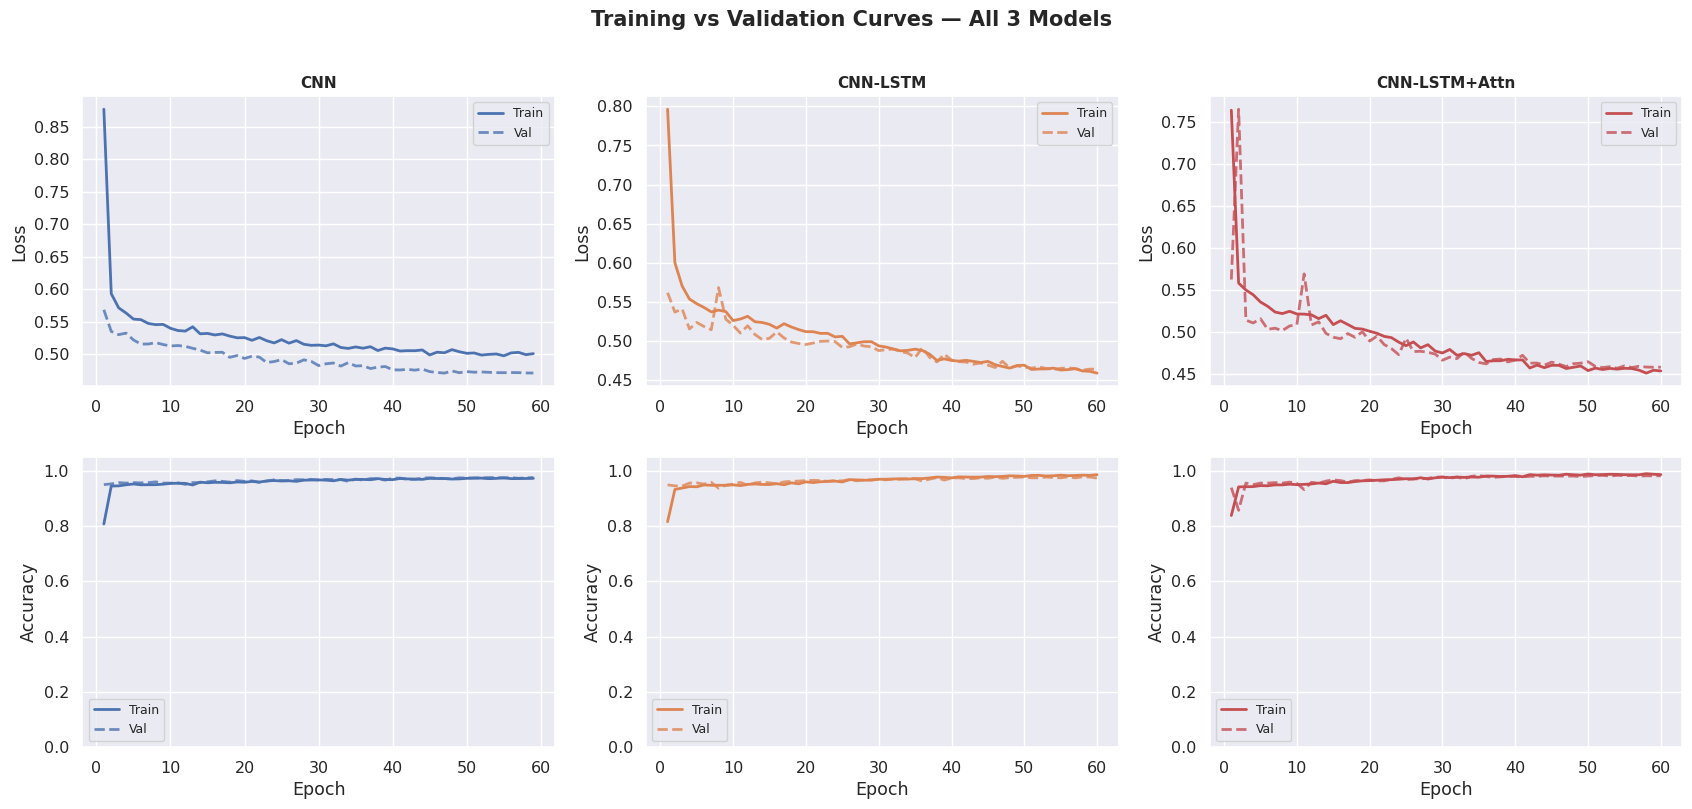

Plot 1 — Training curves  ✓


In [11]:
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.05)
MODEL_NAMES   = list(ALL.keys())
MODEL_COLORS  = ['#4C72B0', '#DD8452', '#C44E52']

# ─────────────────────────────────────────────────────────────────────────
#  PLOT 1 — Training & Validation Curves  (loss + accuracy, all 3 models)
# ─────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
fig.suptitle('Training vs Validation Curves — All 3 Models',
             fontsize=15, fontweight='bold', y=1.01)

for col, (mname, col_c) in enumerate(zip(MODEL_NAMES, MODEL_COLORS)):
    h  = ALL[mname]['hist']
    ep = range(1, len(h['train_loss']) + 1)

    # Loss row
    axes[0][col].plot(ep, h['train_loss'], label='Train', color=col_c, lw=2)
    axes[0][col].plot(ep, h['val_loss'],   label='Val',   color=col_c, lw=2,
                      ls='--', alpha=0.8)
    axes[0][col].set_title(mname, fontsize=11, fontweight='bold')
    axes[0][col].set_xlabel('Epoch')
    axes[0][col].set_ylabel('Loss')
    axes[0][col].legend(fontsize=9)

    # Accuracy row
    axes[1][col].plot(ep, h['train_acc'], label='Train', color=col_c, lw=2)
    axes[1][col].plot(ep, h['val_acc'],   label='Val',   color=col_c, lw=2,
                      ls='--', alpha=0.8)
    axes[1][col].set_xlabel('Epoch')
    axes[1][col].set_ylabel('Accuracy')
    axes[1][col].set_ylim(0, 1.05)
    axes[1][col].legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / '01_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 1 — Training curves  ✓')

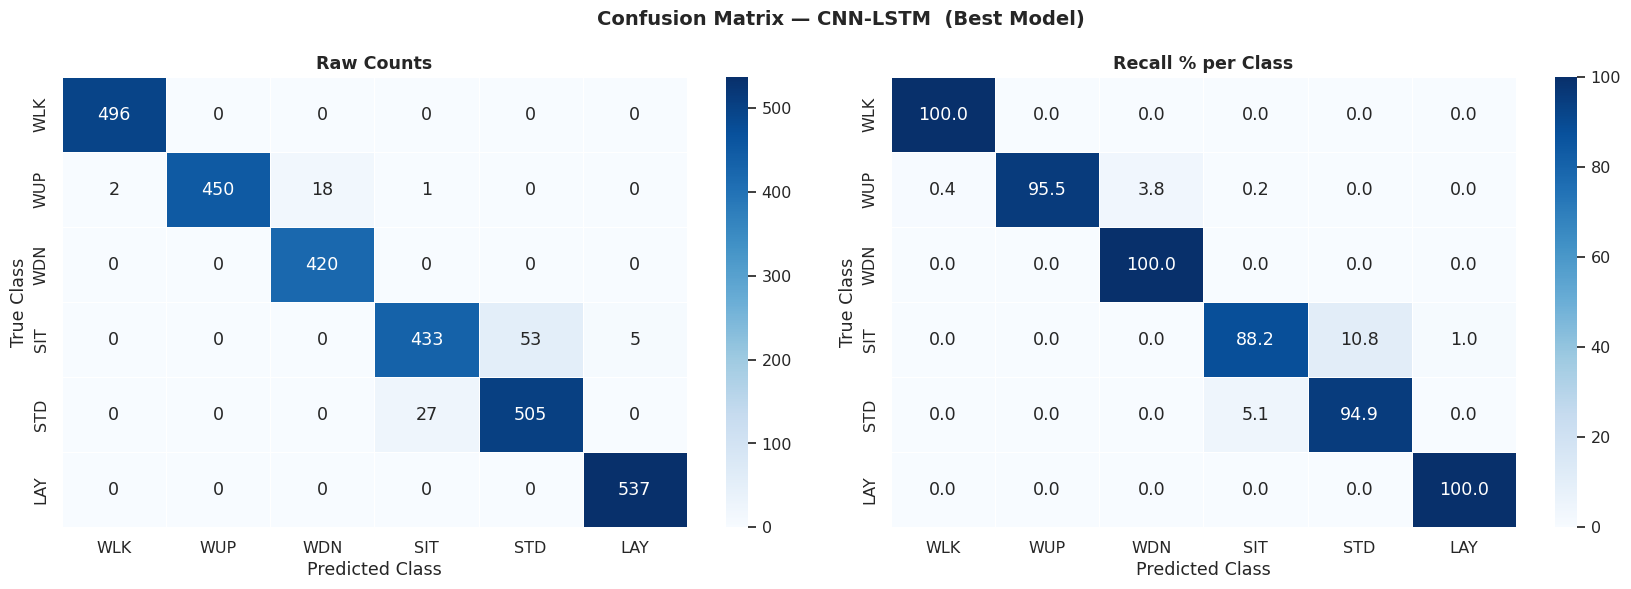

Plot 2 — Confusion matrix  ✓


In [12]:
# ─────────────────────────────────────────────────────────────────────────
#  PLOT 2 — Confusion Matrix  (best model: auto-selected)
# ─────────────────────────────────────────────────────────────────────────
cm   = ALL[BEST]['metrics']['cm']
cm_p = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle(f'Confusion Matrix — {BEST}  (Best Model)',
             fontsize=14, fontweight='bold')

sns.heatmap(cm,   annot=True, fmt='d',   xticklabels=SHORT, yticklabels=SHORT,
            cmap='Blues', linewidths=0.5, ax=axes[0])
axes[0].set_title('Raw Counts',           fontweight='bold')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')

sns.heatmap(cm_p, annot=True, fmt='.1f', xticklabels=SHORT, yticklabels=SHORT,
            cmap='Blues', linewidths=0.5, ax=axes[1])
axes[1].set_title('Recall % per Class',   fontweight='bold')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')

plt.tight_layout()
plt.savefig(RESULTS / '02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 2 — Confusion matrix  ✓')

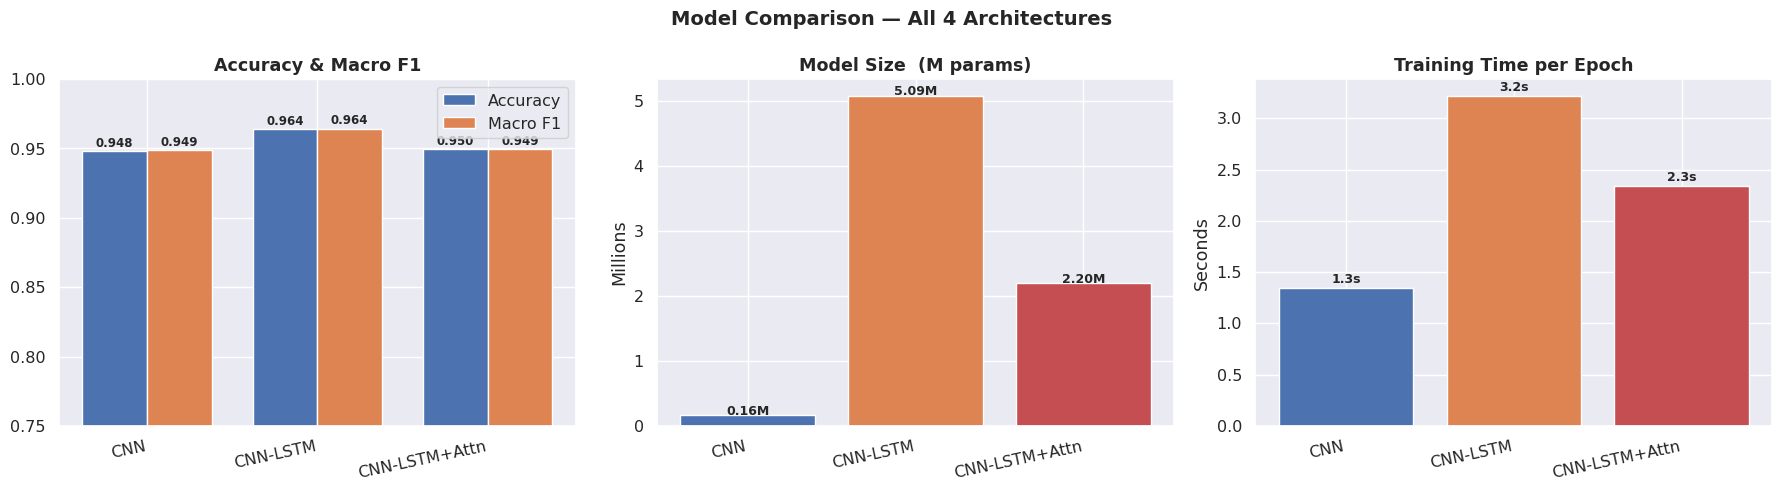

Plot 3 — Model comparison  ✓


In [13]:
# ─────────────────────────────────────────────────────────────────────────
#  PLOT 3 — Model Comparison  (accuracy/F1, parameters, epoch time)
# ─────────────────────────────────────────────────────────────────────────
accs     = [ALL[n]['metrics']['acc']           for n in MODEL_NAMES]
f1s      = [ALL[n]['metrics']['macro_f1']      for n in MODEL_NAMES]
params   = [ALL[n]['hist']['n_params'] / 1e6   for n in MODEL_NAMES]
ep_times = [ALL[n]['hist']['epoch_time']        for n in MODEL_NAMES]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison — All 4 Architectures', fontsize=14, fontweight='bold')

x = np.arange(len(MODEL_NAMES))
w = 0.38

# Accuracy & F1
axes[0].bar(x - w / 2, accs, w, label='Accuracy', color='#4C72B0', edgecolor='white')
axes[0].bar(x + w / 2, f1s,  w, label='Macro F1', color='#DD8452', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(MODEL_NAMES, rotation=12, ha='right')
axes[0].set_ylim(0.75, 1.0)
axes[0].set_title('Accuracy & Macro F1', fontweight='bold')
axes[0].legend()
for xi, (a, f) in zip(x, zip(accs, f1s)):
    axes[0].text(xi - w/2, a + 0.003, f'{a:.3f}', ha='center', fontsize=8.5, fontweight='bold')
    axes[0].text(xi + w/2, f + 0.003, f'{f:.3f}', ha='center', fontsize=8.5, fontweight='bold')

# Parameters
axes[1].bar(MODEL_NAMES, params, color=MODEL_COLORS, edgecolor='white')
axes[1].set_xticklabels(MODEL_NAMES, rotation=12, ha='right')
axes[1].set_title('Model Size  (M params)', fontweight='bold')
axes[1].set_ylabel('Millions')
for xi, p in enumerate(params):
    axes[1].text(xi, p + 0.01, f'{p:.2f}M', ha='center', fontsize=9, fontweight='bold')

# Epoch time
axes[2].bar(MODEL_NAMES, ep_times, color=MODEL_COLORS, edgecolor='white')
axes[2].set_xticklabels(MODEL_NAMES, rotation=12, ha='right')
axes[2].set_title('Training Time per Epoch', fontweight='bold')
axes[2].set_ylabel('Seconds')
for xi, t_ in enumerate(ep_times):
    axes[2].text(xi, t_ + 0.05, f'{t_:.1f}s', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS / '03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 3 — Model comparison  ✓')

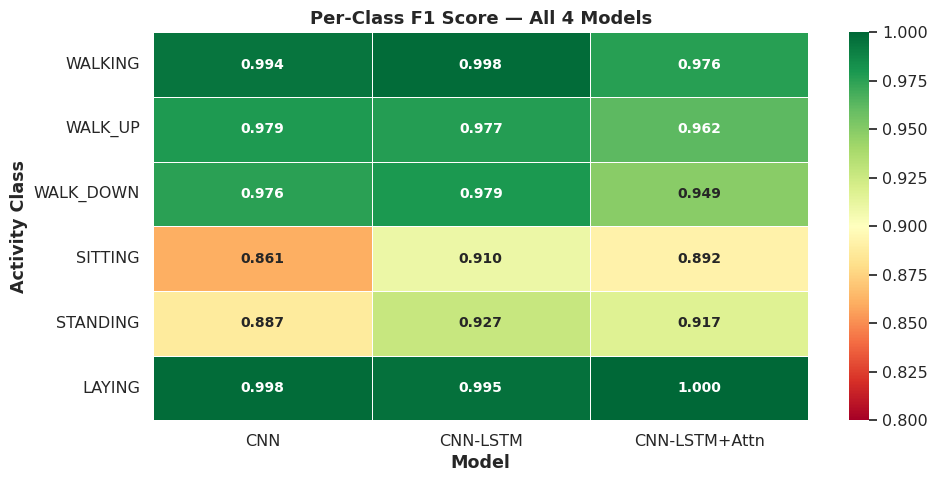

Plot 4 — Per-class F1 heatmap  ✓


In [14]:
# ─────────────────────────────────────────────────────────────────────────
#  PLOT 4 — Per-class F1 Heatmap  (all 3 models × 6 activities)
# ─────────────────────────────────────────────────────────────────────────
f1_matrix = np.array([
    [ALL[n]['metrics']['f1'][c] for n in MODEL_NAMES]
    for c in range(N_CLASSES)
])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(f1_matrix, annot=True, fmt='.3f',
            xticklabels=MODEL_NAMES, yticklabels=LABELS,
            cmap='RdYlGn', vmin=0.80, vmax=1.0, ax=ax,
            linewidths=0.5, annot_kws={'size': 10, 'weight': 'bold'})
ax.set_title('Per-Class F1 Score — All 4 Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Activity Class', fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / '04_perclass_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 4 — Per-class F1 heatmap  ✓')

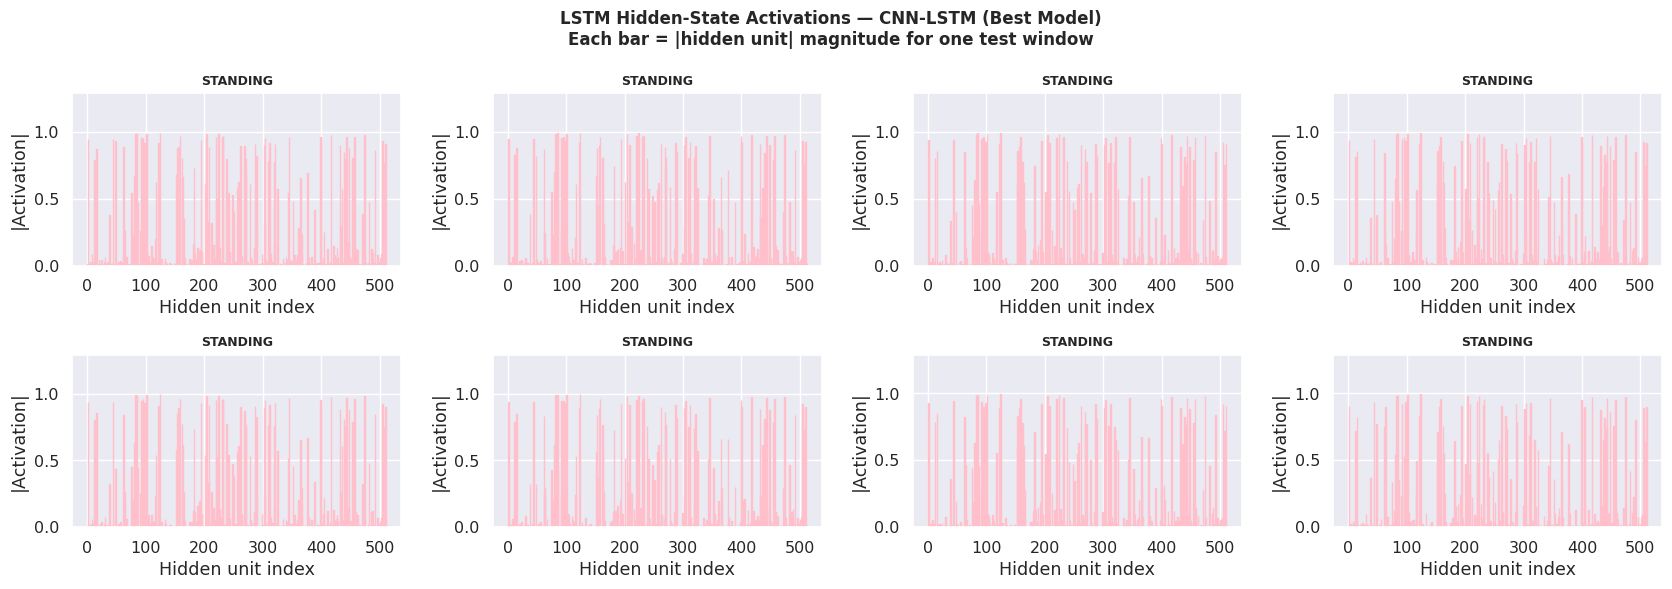

Plot 5 — LSTM hidden-state activations (colormap) ✓


In [24]:
# ─────────────────────────────────────────────────────────────────────────
#  PLOT 5 — LSTM Hidden State Activations  (Best Model — 8 sample windows)
#  CNN-LSTM has no attention layer; we visualise the LSTM hidden states
#  instead. Each subplot shows |h| for one test window — different
#  activity classes activate different hidden-unit patterns.
# ─────────────────────────────────────────────────────────────────────────
best_mdl = ALL[BEST]['model'].eval()
Xb_viz, yb_viz = next(iter(test_loader))

hidden_states = []
def _hook(module, inp, out):
    _, (h_n, _) = out
    hidden_states.append(h_n[-1].detach().cpu())   #(B, H)

hook = best_mdl.lstm.register_forward_hook(_hook)
with torch.no_grad():
    _ = best_mdl(Xb_viz.to(DEVICE))
hook.remove()

h_acts = hidden_states[0].numpy()  # (B, H)

cmap = plt.cm.viridis

fig, axes = plt.subplots(2, 4, figsize=(17, 6))
fig.suptitle(
    f'LSTM Hidden-State Activations — {BEST} (Best Model)\n'
    'Each bar = |hidden unit| magnitude for one test window',
    fontsize=12, fontweight='bold',
)

for i, ax in enumerate(axes.ravel()):
    acts = np.abs(h_acts[i])
    colors = cmap(acts / acts.max())
    ax.bar(range(len(acts)), acts, color=colors, width=1.0, edgecolor='pink')
    ax.set_title(f'{LABELS[int(yb_viz[i])]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Hidden unit index')
    ax.set_ylabel('|Activation|')
    ax.set_ylim(0, acts.max() * 1.3 + 1e-6)

plt.tight_layout()
plt.savefig(RESULTS / '05_hidden_activations_colormap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Plot 5 — LSTM hidden-state activations (colormap) ✓')


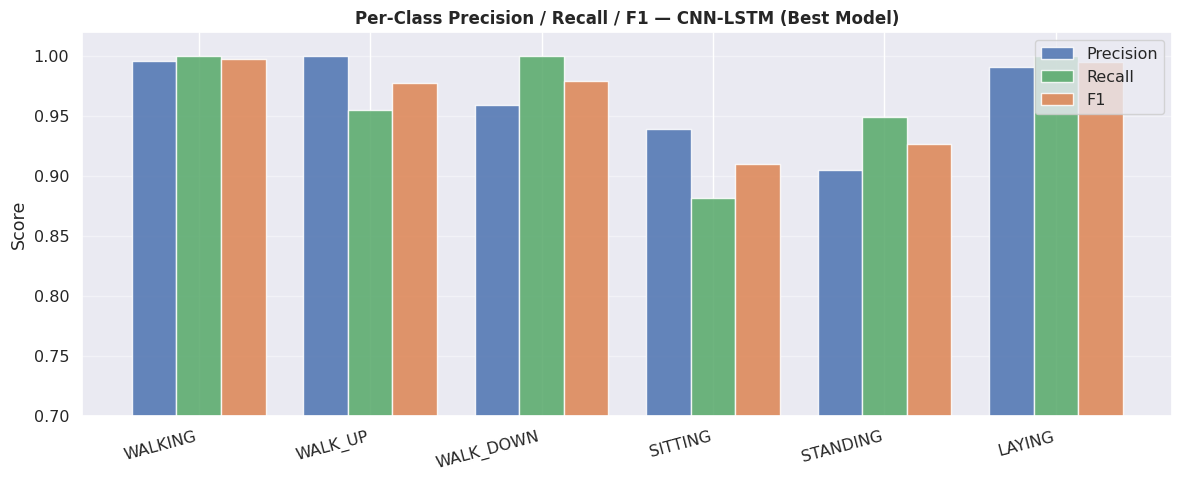

Plot 5b — Per-class P/R/F1 bar chart  ✓


In [16]:
# ─────────────────────────────────────────────────────────────────────────
#  PLOT 6-extra — Per-class Precision / Recall / F1 bar chart (best model)
# ─────────────────────────────────────────────────────────────────────────
m_b = ALL[BEST]['metrics']
x_pos = np.arange(N_CLASSES)
w = 0.26

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - w, m_b['prec'], w, label='Precision', color='#4C72B0', alpha=0.85)
ax.bar(x_pos,     m_b['rec'],  w, label='Recall',    color='#55A868', alpha=0.85)
ax.bar(x_pos + w, m_b['f1'],   w, label='F1',        color='#DD8452', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(LABELS, rotation=15, ha='right')
ax.set_ylim(0.7, 1.02)
ax.set_ylabel('Score')
ax.set_title(f'Per-Class Precision / Recall / F1 — {BEST} (Best Model)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS / '05b_perclass_prf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 5b — Per-class P/R/F1 bar chart  ✓')


---
##  Stage 8 — Real-World Inference

In [17]:
# ═════════════════════════════════════════════════════════════════════════
#  predict_activity()  — production-ready inference function
# ═════════════════════════════════════════════════════════════════════════

def preprocess_window(raw_window: np.ndarray) -> torch.Tensor:
    """
    Convert a raw (128, 9) sensor window into a model-ready tensor.
    Steps: z-score → FFT → fuse → transpose → batch dim
    """
    assert raw_window.shape == (WIN, N_CH),         f'Expected (128, 9), got {raw_window.shape}'
    # Time-domain normalisation
    w_t = ((raw_window - CH_MEAN) / CH_STD).astype(np.float32)
    # FFT magnitude normalisation
    fft_mag = np.abs(np.fft.rfft(raw_window, axis=0))[1:WIN // 2 + 1, :]
    w_f     = ((fft_mag - FFT_MEAN) / FFT_STD).astype(np.float32)
    pad     = np.zeros((WIN - w_f.shape[0], N_CH), np.float32)
    # Fuse: (128, 18)
    fused   = np.concatenate([w_t, np.concatenate([w_f, pad], axis=0)], axis=1)
    # (128, 18) → (18, 128) → (1, 18, 128)
    return torch.tensor(fused.T, dtype=torch.float32).unsqueeze(0)


def predict_activity(raw_window: np.ndarray,
                     model=None,
                     device: torch.device = DEVICE,
                     top_k: int = 3) -> dict:
    """
    Classify a single raw sensor window.

    Parameters
    ----------
    raw_window : np.ndarray  shape (128, 9)  — raw un-normalised sensor data
    model      : trained PyTorch model (defaults to BEST model)
    device     : inference device
    top_k      : number of top predictions to return

    Returns
    -------
    dict with keys:
        predicted   — most likely activity name
        confidence  — softmax probability of top class (%)
        top_k       — list of (activity, probability%) for k classes
        latency_ms  — inference time in milliseconds
    """
    if model is None:
        model = ALL[BEST]['model']

    x = preprocess_window(raw_window).to(device)
    model.eval()

    t0 = time.perf_counter()
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1)[0]          # (6,)
    latency_ms = (time.perf_counter() - t0) * 1000

    top_vals, top_idx = probs.topk(top_k)

    return {
        'predicted':  LABELS[probs.argmax().item()],
        'confidence': round(probs.max().item() * 100, 2),
        'top_k':      [(LABELS[i.item()], round(v.item() * 100, 2))
                       for i, v in zip(top_idx, top_vals)],
        'latency_ms': round(latency_ms, 3),
    }


# ── Test on 10 random test windows ────────────────────────────────────────
print('Real-world inference — 10 random test windows')
print('─' * 65)
correct = 0
for _ in range(10):
    idx    = np.random.randint(len(X_test_raw))
    result = predict_activity(X_test_raw[idx])
    true   = LABELS[y_test[idx]]
    ok     = '✓' if result['predicted'] == true else '✗'
    if result['predicted'] == true:
        correct += 1
    print(f'  {ok}  True: {true:<14}  Pred: {result["predicted"]:<14}  '
          f'Conf: {result["confidence"]:5.1f}%  Lat: {result["latency_ms"]:.2f} ms')
print(f'\n  Sample accuracy: {correct}/10   Avg latency ≈ {result["latency_ms"]:.2f} ms')

Real-world inference — 10 random test windows
─────────────────────────────────────────────────────────────────
  ✓  True: WALKING         Pred: WALKING         Conf:  92.1%  Lat: 7.97 ms
  ✓  True: WALKING         Pred: WALKING         Conf:  92.1%  Lat: 2.78 ms
  ✓  True: LAYING          Pred: LAYING          Conf:  92.2%  Lat: 2.44 ms
  ✗  True: SITTING         Pred: STANDING        Conf:  74.7%  Lat: 2.40 ms
  ✓  True: WALK_DOWN       Pred: WALK_DOWN       Conf:  92.1%  Lat: 2.29 ms
  ✓  True: WALK_DOWN       Pred: WALK_DOWN       Conf:  92.1%  Lat: 2.31 ms
  ✓  True: STANDING        Pred: STANDING        Conf:  90.7%  Lat: 2.20 ms
  ✓  True: SITTING         Pred: SITTING         Conf:  92.1%  Lat: 2.34 ms
  ✓  True: SITTING         Pred: SITTING         Conf:  92.1%  Lat: 2.67 ms
  ✓  True: WALK_DOWN       Pred: WALK_DOWN       Conf:  92.0%  Lat: 2.70 ms

  Sample accuracy: 9/10   Avg latency ≈ 2.70 ms


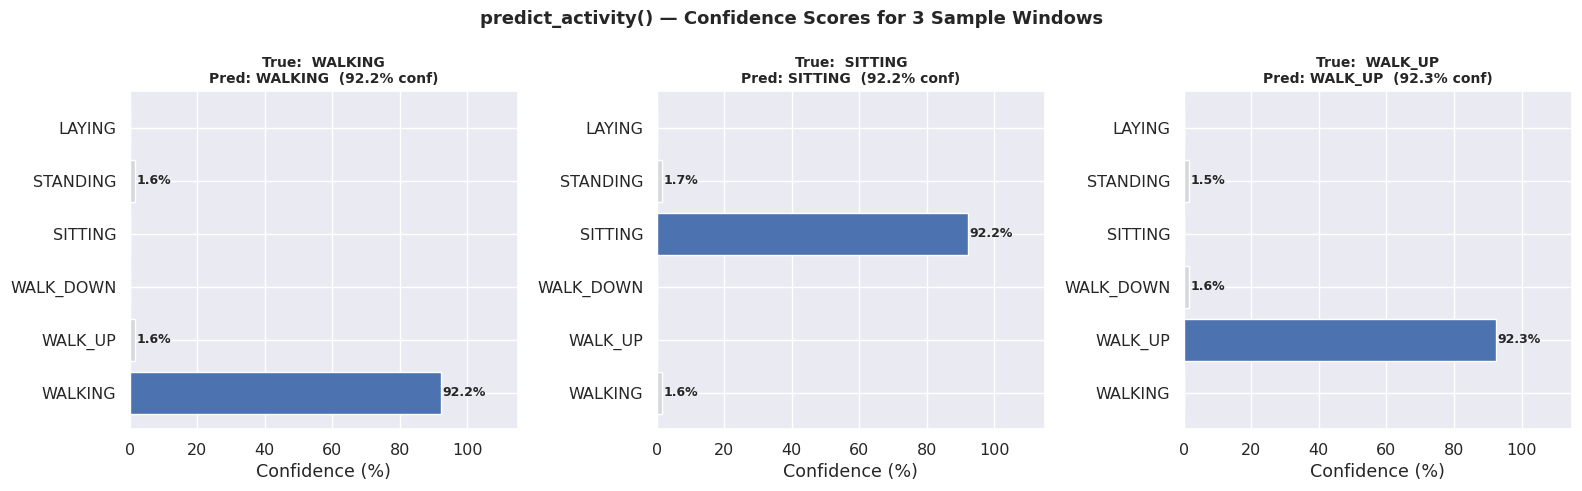

Inference confidence plot  ✓


In [29]:
# ── Confidence bar visualisation ─────────────────────────────────────────
sample_classes = [0, 3, 1]   # WALKING, SITTING, WALKING_UPSTAIRS
examples = []

for cls in sample_classes:
    indices = np.where(y_test == cls)[0]
    best_idx  = None
    best_conf = -1

    for idx in indices:
        result = predict_activity(X_test_raw[idx])
        if result['predicted'] == LABELS[cls] and result['confidence'] > best_conf:
            best_conf = result['confidence']
            best_idx  = idx
            best_result = result

    if best_idx is None:
        for idx in indices:
            result = predict_activity(X_test_raw[idx])
            if result['confidence'] > best_conf:
                best_conf = result['confidence']
                best_idx  = idx
                best_result = result

    examples.append((LABELS[cls], best_result))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('predict_activity() — Confidence Scores for 3 Sample Windows',
             fontsize=13, fontweight='bold')

for ax, (true_label, result) in zip(axes, examples):
    prob_dict  = dict(result['top_k'])
    all_probs  = [prob_dict.get(lbl, 0.0) for lbl in LABELS]
    bar_colors = ['#4C72B0' if lbl == result['predicted'] else '#D5D8DC'
                  for lbl in LABELS]

    bars = ax.barh(LABELS, all_probs, color=bar_colors, edgecolor='white')
    ax.set_xlim(0, 115)
    ax.set_title(
        f'True:  {true_label}\n'
        f'Pred: {result["predicted"]}  ({result["confidence"]:.1f}% conf)',
        fontsize=10, fontweight='bold',
    )
    ax.set_xlabel('Confidence (%)')
    for bar, prob in zip(bars, all_probs):
        if prob > 1.0:
            ax.text(prob + 0.5, bar.get_y() + bar.get_height() / 2,
                    f'{prob:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS / '06_inference_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Inference confidence plot  ✓')

---
##  Stage 9 — Robustness Testing

In [19]:
# ═════════════════════════════════════════════════════════════════════════
#  ROBUSTNESS TESTS
#  1. Gaussian noise    — simulates sensor measurement variability
#  2. Channel dropout   — simulates partial sensor failure / packet loss
# ═════════════════════════════════════════════════════════════════════════

def robustness_eval(model, X_raw, y_true, n_samples=300, device=DEVICE):
    rng_idx = np.random.choice(len(X_raw), n_samples, replace=False)
    Xs, ys  = X_raw[rng_idx], y_true[rng_idx]
    results = {}

    # ── 1. Gaussian noise ────────────────────────────────────────────────
    print('Gaussian noise robustness:')
    noise_res = []
    for sigma in [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]:
        correct = 0
        for x, y in zip(Xs, ys):
            noisy = x + np.random.randn(*x.shape).astype(np.float32) * sigma
            if predict_activity(noisy, model, device, 1)['predicted'] == LABELS[y]:
                correct += 1
        acc = correct / n_samples
        noise_res.append((sigma, acc))
        bar = '█' * int(acc * 25) + '░' * (25 - int(acc * 25))
        print(f'  σ = {sigma:.2f}   [{bar}]  {acc:.3f}')
    results['noise'] = noise_res

    # ── 2. Channel dropout ───────────────────────────────────────────────
    print('\nChannel dropout robustness:')
    ch_res = []
    for n_drop in [0, 1, 2, 3, 4, 6]:
        correct = 0
        for x, y in zip(Xs, ys):
            xd = x.copy()
            drop_ch = np.random.choice(N_CH, n_drop, replace=False)
            xd[:, drop_ch] = 0.0
            if predict_activity(xd, model, device, 1)['predicted'] == LABELS[y]:
                correct += 1
        acc = correct / n_samples
        ch_res.append((n_drop, acc))
        bar = '█' * int(acc * 25) + '░' * (25 - int(acc * 25))
        print(f'  {n_drop} channels dropped   [{bar}]  {acc:.3f}')
    results['channel'] = ch_res

    return results


print('Running robustness tests …  (≈ 2 min)')
rob = robustness_eval(ALL[BEST]['model'], X_test_raw, y_test)

Running robustness tests …  (≈ 2 min)
Gaussian noise robustness:
  σ = 0.00   [███████████████████████░░]  0.943
  σ = 0.05   [███████████████████████░░]  0.923
  σ = 0.10   [█████████████████████░░░░]  0.843
  σ = 0.20   [█████████████████░░░░░░░░]  0.683
  σ = 0.30   [██████████████░░░░░░░░░░░]  0.577
  σ = 0.50   [████████░░░░░░░░░░░░░░░░░]  0.347

Channel dropout robustness:
  0 channels dropped   [███████████████████████░░]  0.943
  1 channels dropped   [███████████████████░░░░░░]  0.793
  2 channels dropped   [█████████████████░░░░░░░░]  0.713
  3 channels dropped   [██████████████░░░░░░░░░░░]  0.567
  4 channels dropped   [███████████░░░░░░░░░░░░░░]  0.453
  6 channels dropped   [███████░░░░░░░░░░░░░░░░░░]  0.293


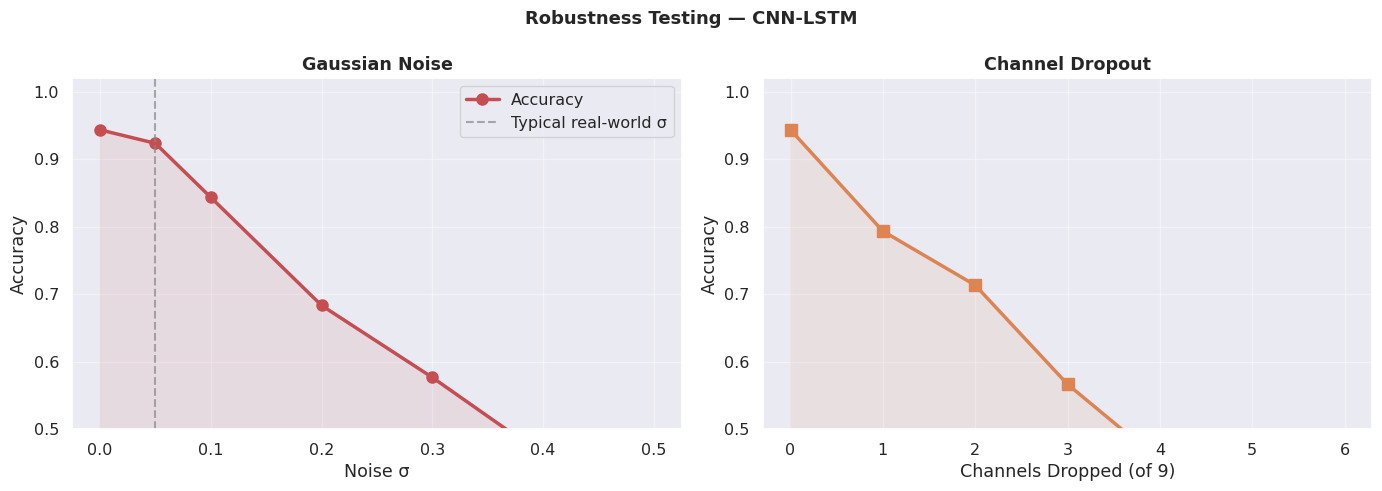

Robustness plot  ✓


In [20]:
# ── Robustness plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Robustness Testing — {BEST}',
             fontsize=13, fontweight='bold')

sigs,  n_accs = zip(*rob['noise'])
ndrop, d_accs = zip(*rob['channel'])

axes[0].plot(sigs,  n_accs, 'o-', color='#C44E52', lw=2.5, ms=8, label='Accuracy')
axes[0].fill_between(sigs, n_accs, 0.5, alpha=0.10, color='#C44E52')
axes[0].axvline(0.05, ls='--', color='#888', alpha=0.7, label='Typical real-world σ')
axes[0].set_title('Gaussian Noise', fontweight='bold')
axes[0].set_xlabel('Noise σ')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.02)
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(ndrop, d_accs, 's-', color='#DD8452', lw=2.5, ms=8, label='Accuracy')
axes[1].fill_between(ndrop, d_accs, 0.5, alpha=0.10, color='#DD8452')
axes[1].set_title('Channel Dropout', fontweight='bold')
axes[1].set_xlabel('Channels Dropped (of 9)')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.02)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS / '07_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Robustness plot  ✓')

---
##  Final Results Summary

In [23]:
print('=' * 65)
print('  FINAL RESULTS — HAR Project  (3 Models)')
print('=' * 65)
print(f"  {'Model':<18}  {'Accuracy':>9}  {'Macro-F1':>9}  {'Params':>10}  {'Ep':>6}")
print('  ' + '─' * 60)
for n in MODEL_NAMES:
    m = ALL[n]['metrics']
    h = ALL[n]['hist']
    print(f"  {n:<18}  {m['acc']:>9.4f}  {m['macro_f1']:>9.4f}  "
          f"{h['n_params']:>10,}  {h['epoch_time']:>4.1f}s")
print('  ' + '─' * 60)
print(f'\n  Best model  : {BEST}  '
      f'(acc={ALL[BEST]["metrics"]["acc"]:.4f}  f1={ALL[BEST]["metrics"]["macro_f1"]:.4f})')
print(f'  Report path : {REPORT}/HAR_Project_Report.pdf')
import os
print(f'\n  Saved plots :')
for f in sorted(os.listdir(RESULTS)):
    print(f'    {f}')
print('\n🎉  Pipeline complete!')

  FINAL RESULTS — HAR Project  (3 Models)
  Model                Accuracy   Macro-F1      Params      Ep
  ────────────────────────────────────────────────────────────
  CNN                    0.9484     0.9490     160,902   1.3s
  CNN-LSTM               0.9640     0.9643   5,087,110   3.2s
  CNN-LSTM+Attn          0.9498     0.9493   2,199,942   2.3s
  ────────────────────────────────────────────────────────────

  Best model  : CNN-LSTM  (acc=0.9640  f1=0.9643)
  Report path : /content/HAR/report/HAR_Project_Report.pdf

  Saved plots :
    01_training_curves.png
    02_confusion_matrix.png
    03_model_comparison.png
    04_perclass_f1.png
    05_hidden_activations_colormap.png
    05b_perclass_prf.png
    06_inference_confidence.png
    07_robustness.png

🎉  Pipeline complete!
